In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import Dataset, Reader
from surprise import SVD, KNNBasic, KNNWithMeans
from surprise.model_selection import train_test_split, cross_validate
from surprise import accuracy
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")
print("Using Surprise library for Collaborative Filtering")

✅ Libraries imported successfully!
Using Surprise library for Collaborative Filtering


In [2]:
# Load the cleaned data
ratings = pd.read_csv('../data/processed/ratings_clean.csv')
movies = pd.read_csv('../data/processed/movies_clean.csv')

print("✅ Data loaded successfully!")
print(f"Ratings: {ratings.shape}")
print(f"Movies: {movies.shape}")
print(f"\nSample ratings:")
print(ratings.head())

✅ Data loaded successfully!
Ratings: (100836, 7)
Movies: (9742, 3)

Sample ratings:
   userId  movieId  rating  timestamp             datetime  year  month
0       1        1     4.0  964982703  2000-07-30 18:45:03  2000      7
1       1        3     4.0  964981247  2000-07-30 18:20:47  2000      7
2       1        6     4.0  964982224  2000-07-30 18:37:04  2000      7
3       1       47     5.0  964983815  2000-07-30 19:03:35  2000      7
4       1       50     5.0  964982931  2000-07-30 18:48:51  2000      7


In [3]:
# Surprise requires specific format
# Define a Reader with rating scale
reader = Reader(rating_scale=(0.5, 5.0))

# Load data into Surprise Dataset
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

print("✅ Data prepared for Surprise library")
print(f"Rating scale: 0.5 to 5.0")

✅ Data prepared for Surprise library
Rating scale: 0.5 to 5.0


In [4]:
# Split data into train and test sets (80-20 split)
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

print("="*70)
print("TRAIN-TEST SPLIT")
print("="*70)
print(f"Training set size: {trainset.n_ratings:,} ratings")
print(f"Test set size: {len(testset):,} ratings")
print(f"Split ratio: 80-20")
print(f"\nUsers in trainset: {trainset.n_users}")
print(f"Items in trainset: {trainset.n_items}")

TRAIN-TEST SPLIT
Training set size: 80,668 ratings
Test set size: 20,168 ratings
Split ratio: 80-20

Users in trainset: 610
Items in trainset: 8928


In [5]:
print("\n" + "="*70)
print("TRAINING SVD (MATRIX FACTORIZATION) MODEL")
print("="*70)

# Initialize SVD with parameters
svd_model = SVD(
    n_factors=100,      # Number of latent factors
    n_epochs=20,        # Number of training iterations
    lr_all=0.005,       # Learning rate
    reg_all=0.02,       # Regularization term
    random_state=42
)

# Train the model
print("\nTraining SVD model...")
import time
start_time = time.time()
svd_model.fit(trainset)
training_time = time.time() - start_time

print(f"✅ Training complete in {training_time:.2f} seconds")

# Test the model
print("\nEvaluating on test set...")
predictions_svd = svd_model.test(testset)

# Calculate RMSE and MAE
rmse_svd = accuracy.rmse(predictions_svd, verbose=False)
mae_svd = accuracy.mae(predictions_svd, verbose=False)

print(f"\nSVD Results:")
print(f"  RMSE: {rmse_svd:.4f}")
print(f"  MAE:  {mae_svd:.4f}")


TRAINING SVD (MATRIX FACTORIZATION) MODEL

Training SVD model...
✅ Training complete in 0.38 seconds

Evaluating on test set...

SVD Results:
  RMSE: 0.8807
  MAE:  0.6766


In [6]:
print("\n" + "="*70)
print("TRAINING USER-BASED COLLABORATIVE FILTERING")
print("="*70)

# User-based CF using cosine similarity
sim_options_user = {
    'name': 'cosine',
    'user_based': True,
    'min_support': 5
}

knn_user = KNNBasic(k=40, sim_options=sim_options_user, verbose=False)

print("\nTraining User-Based CF...")
start_time = time.time()
knn_user.fit(trainset)
training_time = time.time() - start_time

print(f"✅ Training complete in {training_time:.2f} seconds")

# Test the model
print("\nEvaluating on test set...")
predictions_user = knn_user.test(testset)

rmse_user = accuracy.rmse(predictions_user, verbose=False)
mae_user = accuracy.mae(predictions_user, verbose=False)

print(f"\nUser-Based CF Results:")
print(f"  RMSE: {rmse_user:.4f}")
print(f"  MAE:  {mae_user:.4f}")


TRAINING USER-BASED COLLABORATIVE FILTERING

Training User-Based CF...
✅ Training complete in 0.09 seconds

Evaluating on test set...

User-Based CF Results:
  RMSE: 0.9828
  MAE:  0.7566


In [7]:
print("\n" + "="*70)
print("TRAINING ITEM-BASED COLLABORATIVE FILTERING")
print("="*70)

# Item-based CF using cosine similarity
sim_options_item = {
    'name': 'cosine',
    'user_based': False,  # Item-based
    'min_support': 5
}

knn_item = KNNBasic(k=40, sim_options=sim_options_item, verbose=False)

print("\nTraining Item-Based CF...")
start_time = time.time()
knn_item.fit(trainset)
training_time = time.time() - start_time

print(f"✅ Training complete in {training_time:.2f} seconds")

# Test the model
print("\nEvaluating on test set...")
predictions_item = knn_item.test(testset)

rmse_item = accuracy.rmse(predictions_item, verbose=False)
mae_item = accuracy.mae(predictions_item, verbose=False)

print(f"\nItem-Based CF Results:")
print(f"  RMSE: {rmse_item:.4f}")
print(f"  MAE:  {mae_item:.4f}")


TRAINING ITEM-BASED COLLABORATIVE FILTERING

Training Item-Based CF...
✅ Training complete in 2.25 seconds

Evaluating on test set...

Item-Based CF Results:
  RMSE: 0.9772
  MAE:  0.7435



MODEL COMPARISON
        Model     RMSE      MAE
          SVD 0.880746 0.676573
User-Based CF 0.982755 0.756643
Item-Based CF 0.977224 0.743451


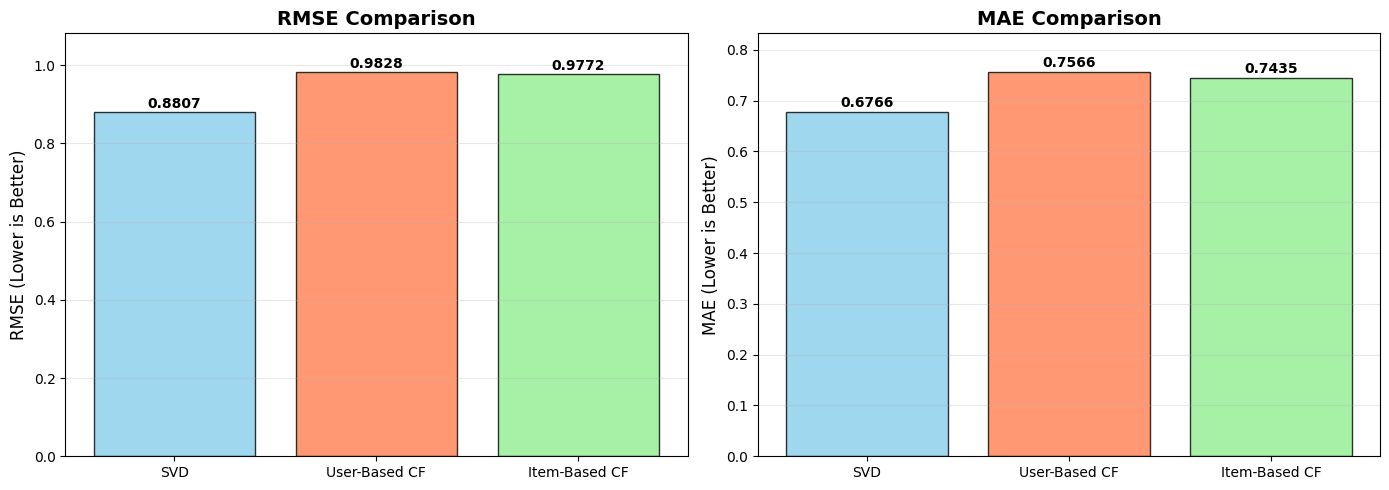


✅ Best Model: SVD (Lowest RMSE)


In [8]:
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)

# Create comparison dataframe
results = pd.DataFrame({
    'Model': ['SVD', 'User-Based CF', 'Item-Based CF'],
    'RMSE': [rmse_svd, rmse_user, rmse_item],
    'MAE': [mae_svd, mae_user, mae_item]
})

print(results.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
axes[0].bar(results['Model'], results['RMSE'], color=['skyblue', 'coral', 'lightgreen'], 
            edgecolor='black', alpha=0.8)
axes[0].set_title('RMSE Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('RMSE (Lower is Better)', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, max(results['RMSE']) * 1.1])

# Add value labels on bars
for i, v in enumerate(results['RMSE']):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

# MAE comparison
axes[1].bar(results['Model'], results['MAE'], color=['skyblue', 'coral', 'lightgreen'], 
            edgecolor='black', alpha=0.8)
axes[1].set_title('MAE Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('MAE (Lower is Better)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, max(results['MAE']) * 1.1])

# Add value labels on bars
for i, v in enumerate(results['MAE']):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Find best model
best_model = results.loc[results['RMSE'].idxmin(), 'Model']
print(f"\n✅ Best Model: {best_model} (Lowest RMSE)")

In [9]:
def get_top_n_recommendations(model, user_id, n=10):
    """
    Get top-N movie recommendations for a user
    
    Parameters:
    - model: trained Surprise model
    - user_id: ID of the user
    - n: number of recommendations
    
    Returns:
    - List of recommended movies with predicted ratings
    """
    # Get list of all movie IDs
    all_movie_ids = ratings['movieId'].unique()
    
    # Get movies already rated by user
    rated_movies = ratings[ratings['userId'] == user_id]['movieId'].values
    
    # Get movies not yet rated by user
    movies_to_predict = [mid for mid in all_movie_ids if mid not in rated_movies]
    
    # Predict ratings for all unrated movies
    predictions = []
    for movie_id in movies_to_predict:
        pred = model.predict(user_id, movie_id)
        predictions.append((movie_id, pred.est))
    
    # Sort by predicted rating
    predictions.sort(key=lambda x: x[1], reverse=True)
    
    # Get top N
    top_n = predictions[:n]
    
    # Get movie details
    recommendations = []
    for movie_id, pred_rating in top_n:
        movie_info = movies[movies['movieId'] == movie_id]
        if not movie_info.empty:
            movie_info = movie_info.iloc[0]
            recommendations.append({
                'movieId': movie_id,
                'title': movie_info['title'],
                'genres': movie_info['genres'],
                'predicted_rating': pred_rating
            })
    
    return recommendations

print("✅ Recommendation function created!")

✅ Recommendation function created!


In [10]:
# Test with a sample user
test_user_id = 1

print("="*70)
print(f"GENERATING RECOMMENDATIONS FOR USER {test_user_id}")
print("="*70)

# Get user's actual ratings
user_ratings = ratings[ratings['userId'] == test_user_id].merge(movies, on='movieId')
user_ratings = user_ratings.sort_values('rating', ascending=False)

print(f"\nUser {test_user_id}'s Top Rated Movies:")
print("-" * 70)
for idx, row in user_ratings.head(5).iterrows():
    print(f"  ⭐ {row['rating']:.1f} - {row['title']} ({row['genres']})")

# Generate recommendations using SVD
print(f"\n\nTop 10 Recommendations (SVD Model):")
print("-" * 70)
recommendations = get_top_n_recommendations(svd_model, test_user_id, n=10)

for i, rec in enumerate(recommendations, 1):
    print(f"{i:2d}. {rec['title']}")
    print(f"    Predicted Rating: {rec['predicted_rating']:.2f} | Genres: {rec['genres']}")
    print()

GENERATING RECOMMENDATIONS FOR USER 1

User 1's Top Rated Movies:
----------------------------------------------------------------------
  ⭐ 5.0 - M*A*S*H (a.k.a. MASH) (1970) (Comedy|Drama|War)
  ⭐ 5.0 - Excalibur (1981) (Adventure|Fantasy)
  ⭐ 5.0 - Indiana Jones and the Last Crusade (1989) (Action|Adventure)
  ⭐ 5.0 - Pink Floyd: The Wall (1982) (Drama|Musical)
  ⭐ 5.0 - From Russia with Love (1963) (Action|Adventure|Thriller)


Top 10 Recommendations (SVD Model):
----------------------------------------------------------------------
 1. Departed, The (2006)
    Predicted Rating: 5.00 | Genres: Crime|Drama|Thriller

 2. North by Northwest (1959)
    Predicted Rating: 5.00 | Genres: Action|Adventure|Mystery|Romance|Thriller

 3. Casablanca (1942)
    Predicted Rating: 5.00 | Genres: Drama|Romance

 4. Seven Samurai (Shichinin no samurai) (1954)
    Predicted Rating: 5.00 | Genres: Action|Adventure|Drama

 5. Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)


ADVANCED EVALUATION METRICS (Precision@10 & Recall@10)

        Model  Precision@10  Recall@10  F1-Score
          SVD      0.629016   0.655939  0.642196
User-Based CF      0.628852   0.657002  0.642619
Item-Based CF      0.592131   0.640159  0.615209


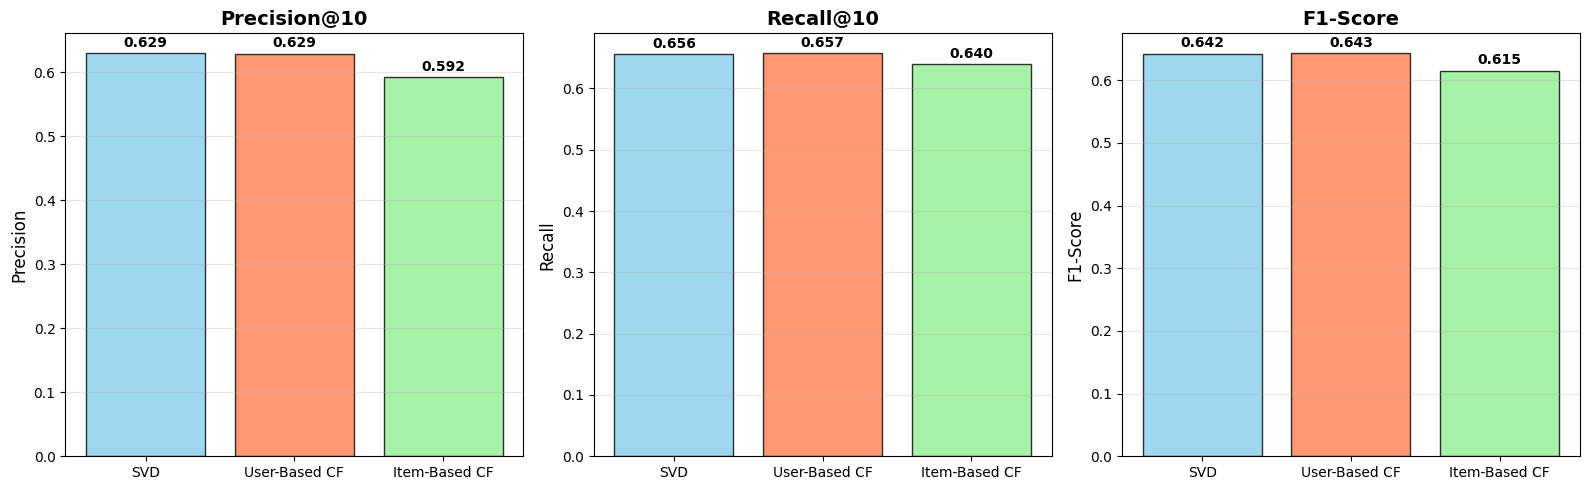

In [11]:
def precision_recall_at_k(predictions, k=10, threshold=3.5):
    """
    Calculate Precision@K and Recall@K
    
    Parameters:
    - predictions: list of predictions from model.test()
    - k: number of recommendations
    - threshold: rating threshold for relevance
    """
    # Group predictions by user
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))
    
    precisions = []
    recalls = []
    
    for uid, user_ratings in user_est_true.items():
        # Sort by estimated rating
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        
        # Top K recommendations
        top_k = user_ratings[:k]
        
        # Number of relevant items in top K
        n_rel_and_rec_k = sum((true_r >= threshold) for (_, true_r) in top_k)
        
        # Total number of relevant items
        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        
        # Precision@K: relevant items in top-k / k
        precisions.append(n_rel_and_rec_k / k if k != 0 else 0)
        
        # Recall@K: relevant items in top-k / total relevant items
        recalls.append(n_rel_and_rec_k / n_rel if n_rel != 0 else 0)
    
    return sum(precisions) / len(precisions), sum(recalls) / len(recalls)

# Calculate for all models
print("="*70)
print("ADVANCED EVALUATION METRICS (Precision@10 & Recall@10)")
print("="*70)

models_dict = {
    'SVD': (svd_model, predictions_svd),
    'User-Based CF': (knn_user, predictions_user),
    'Item-Based CF': (knn_item, predictions_item)
}

advanced_results = []

for name, (model, preds) in models_dict.items():
    precision, recall = precision_recall_at_k(preds, k=10, threshold=3.5)
    advanced_results.append({
        'Model': name,
        'Precision@10': precision,
        'Recall@10': recall,
        'F1-Score': 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    })

advanced_df = pd.DataFrame(advanced_results)
print("\n" + advanced_df.to_string(index=False))

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Precision
axes[0].bar(advanced_df['Model'], advanced_df['Precision@10'], 
            color=['skyblue', 'coral', 'lightgreen'], edgecolor='black', alpha=0.8)
axes[0].set_title('Precision@10', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(advanced_df['Precision@10']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# Recall
axes[1].bar(advanced_df['Model'], advanced_df['Recall@10'], 
            color=['skyblue', 'coral', 'lightgreen'], edgecolor='black', alpha=0.8)
axes[1].set_title('Recall@10', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Recall', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(advanced_df['Recall@10']):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# F1-Score
axes[2].bar(advanced_df['Model'], advanced_df['F1-Score'], 
            color=['skyblue', 'coral', 'lightgreen'], edgecolor='black', alpha=0.8)
axes[2].set_title('F1-Score', fontsize=14, fontweight='bold')
axes[2].set_ylabel('F1-Score', fontsize=12)
axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(advanced_df['F1-Score']):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [13]:
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save all trained models
print("="*70)
print("SAVING MODELS")
print("="*70)

# Save SVD model
with open('../models/svd_model.pkl', 'wb') as f:
    pickle.dump(svd_model, f)
print("✅ SVD model saved to: models/svd_model.pkl")

# Save User-based CF model
with open('../models/knn_user_model.pkl', 'wb') as f:
    pickle.dump(knn_user, f)
print("✅ User-Based CF model saved to: models/knn_user_model.pkl")

# Save Item-based CF model
with open('../models/knn_item_model.pkl', 'wb') as f:
    pickle.dump(knn_item, f)
print("✅ Item-Based CF model saved to: models/knn_item_model.pkl")

# Save evaluation results
results.to_csv('../models/basic_evaluation_results.csv', index=False)
advanced_df.to_csv('../models/advanced_evaluation_results.csv', index=False)
print("✅ Evaluation results saved")

print("\n" + "="*70)
print("✅ COLLABORATIVE FILTERING COMPLETE!")
print("="*70)
print("\nModels trained and evaluated:")
print(f"  • SVD (Matrix Factorization)")
print(f"  • User-Based Collaborative Filtering")
print(f"  • Item-Based Collaborative Filtering")
print(f"\nBest performing model: {best_model}")
print(f"  RMSE: {results.loc[results['RMSE'].idxmin(), 'RMSE']:.4f}")
print("\n" + "="*70)
print("NEXT STEPS:")
print("="*70)
print("1. Create notebook: 03_content_based_filtering.ipynb")
print("2. Implement TF-IDF on genres")
print("3. Calculate content similarity")
print("4. Build hybrid recommender")
print("="*70)

SAVING MODELS
✅ SVD model saved to: models/svd_model.pkl
✅ User-Based CF model saved to: models/knn_user_model.pkl
✅ Item-Based CF model saved to: models/knn_item_model.pkl
✅ Evaluation results saved

✅ COLLABORATIVE FILTERING COMPLETE!

Models trained and evaluated:
  • SVD (Matrix Factorization)
  • User-Based Collaborative Filtering
  • Item-Based Collaborative Filtering

Best performing model: SVD
  RMSE: 0.8807

NEXT STEPS:
1. Create notebook: 03_content_based_filtering.ipynb
2. Implement TF-IDF on genres
3. Calculate content similarity
4. Build hybrid recommender
